In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize

a)

In [ ]:
N=1000
a=0
b=1

def f(x):
    return x**4

def primitive_f(x):
    return 1/5 * x**5

In [ ]:
def monte_carlo(integrand, a, b, N, seed=42):
    """
    integrand: function to integrate via montecarlo
    a: start of integration range
    b>a: end of integration range
    N>1: number of samples to use
    seed: seed for random samples
          (provides reproducible sequences)

    returns: tupel (integration result, error)
    """
    assert N>1, "N must be greater 1"
    V = b - a
    assert V>0, "a<b is needed!"

    random_generator = np.random.default_rng(seed=seed)

    x_samples = random_generator.random((N,))*V + a
    y_samples = integrand(x_samples)
    integrand_mean = y_samples.mean()
    std = np.sqrt(((y_samples**2).mean() - integrand_mean**2)/(N-1))
    return V*integrand_mean, V*std


In [ ]:
I, σ = monte_carlo(f, a, b, 10000, 20)
exact = primitive_f(1)

print(f"monte carlo result: {I}, error {σ}")
print(f"exact result: {exact}")
print(f"{np.abs(I-exact)}")
print(f"{np.abs(I-exact)/σ}")

monte carlo result: 0.2009883529887704, error 0.0027101544381571484
exact result: 0.2
0.0009883529887703968
0.36468511714869556


# b)

In [ ]:
M=1000

def gaussian_bell(x, σ, μ):
    return 1/np.sqrt(2*np.pi)/σ * np.exp(-.5 * ((x-μ)/σ)**2)

In [ ]:
I, σ = np.array([monte_carlo(f,a,b,N,m) for m in range(M)]).T

Text(0, 0.5, 'Density')

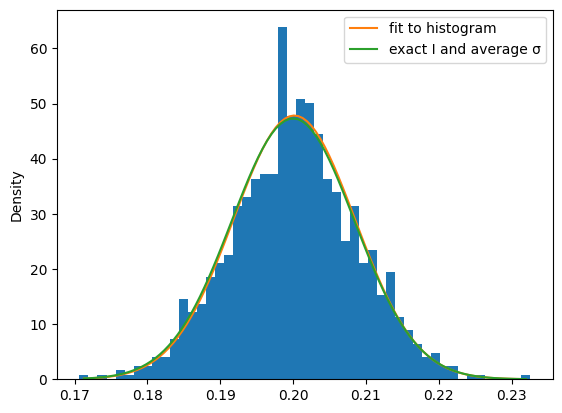

In [ ]:
plt.figure()
y,bin_edges,_ = plt.hist(I, bins=50, density=True)

# Calculate the width of the equal bins
bin_dist = (bin_edges[1] - bin_edges[0])

# Get the middle point of each bin
x = bin_edges[:-1] + bin_dist/2

# Fit the histogram to a gaussian distribution
# with an initial guess for σ=0.002 and a=0.2
(σ_opt, a_opt), cov = optimize.curve_fit(gaussian_bell, x,y, [.002,.2])

x_range=np.linspace(min(x), max(x), 100)
plt.plot(x_range, gaussian_bell(x_range, σ_opt, a_opt), label="fit to histogram")
plt.plot(x_range, gaussian_bell(x_range, σ.mean(), exact), label="exact I and average σ")
plt.legend()
plt.ylabel("Density")

In [ ]:
print('Gaussian fit error: ', σ_opt)
print('Mean calculations error: ', σ.mean())

Gaussian fit error:  0.008461037730972776
Mean calculations error:  0.008431213613554684


# c)

In [ ]:
def monte_carlo_with_importance_sampling(integrand, G_start, G_end, N, g=lambda x:1, G_inverse=lambda x:x, seed=42):
    """
    integrand: function to integrate via montecarlo
    G_start: start of integration range
    G_end>G_start: end of integration range
    N>1: number of samples to use
    g(x)!=0: an approximation of abs(integrand(x)) if available to use for importance
             sampling. G_inverse is needed as well:
    G_inverse(G): the inverse of the integral of G. Note that for its existance
                  g must be integrabale and may not change sign. (no check performed)
    seed: seed for random samples


    returns: tupel (integration result, error)
    """
    assert N>1, "N must be greater 1"
    V = G_end - G_start
    assert V>0, "G_end>G_start is needed!"

    new_integrand = lambda x : integrand(x)/g(x)

    random_generator = np.random.default_rng(seed=seed)
    G_samples = random_generator.random((N,))*V + G_start
    x_samples = G_inverse(G_samples)
    y_samples = new_integrand(x_samples)

    integrand_mean = y_samples.mean()
    std = np.sqrt(((y_samples**2).mean() - integrand_mean**2)/(N-1))
    return V*integrand_mean, V*std


<ipython-input-44-ae0c76a98ed5>:28: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(((y_samples**2).mean() - integrand_mean**2)/(N-1))


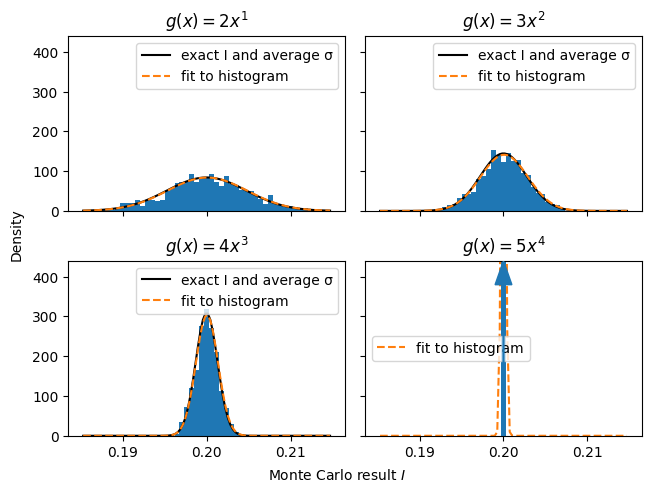

In [ ]:
y_high=440
M = 1000
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)

# Make use of the given g's of the form nx**n-1
for i in range(2,6):
    # Get the coordinates of each subplot lower-left corner
    # as plt.subplots returns them in a np array of the shape:
    # [
    #   [1st row 1st subplot, 1st row 2nd subplot],
    #   [2nd row 1st subplot, 2nd row 2nd subplot]
    # ]
    # These subplots are plt instances which can draw different plots
    ax = axs.flat[i-2]
    g = lambda x : i*x**(i-1)
    G = lambda x : x**i
    G_inverse = lambda x : x**(1/i)

    I, σ = np.array([monte_carlo_with_importance_sampling(f, G(a), G(b), N, g, G_inverse, seed=m) for m in range(M)]).T
    exact = primitive_f(1)
    if not np.all(np.isnan(σ)):
        ax.plot(x_range, gaussian_bell(x_range, σ.mean(), exact), label="exact I and average σ", color="black")

    y,bin_edges,_ = ax.hist(I, bins=51, density=True, range=(.185, .215))
    bin_dist = (bin_edges[1] - bin_edges[0])
    x = bin_edges[:-1] + bin_dist/2

    try:
        (σ_opt, a_opt), cov = optimize.curve_fit(gaussian_bell, x,y, [.002,.2])
    except RuntimeError:
        print("runtime error for", i)
    else:
        x_range=np.linspace(min(x), max(x), 100)
        ax.plot(x_range, gaussian_bell(x_range, σ_opt, a_opt), label="fit to histogram", linestyle="dashed")
    ax.legend(loc=None if i!=5 else "center left")
    ax.set_title(f"$g(x)={i}x^{i-1}$")

# Draw an arrow on the lower-right subplot
# to indicate that the peak is out of the subplot
ax = axs.flat[3]
ax.arrow(exact, 0, 0, y_high, color="C0", width=.0001, head_width=0.002, head_length=60, zorder=100, length_includes_head=True)


fig.text(0.5, 0.0, 'Monte Carlo result $I$', ha='center', va='center')
fig.text(0.0, 0.5, 'Density', ha='center', va='center', rotation='vertical')
# Limit all subplot max y values
# The default is to rescale all subplots
# such that the plot w/ the highest y val is shown completely
plt.ylim(0,y_high)

plt.tight_layout()
plt.show()

<ipython-input-44-ae0c76a98ed5>:28: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(((y_samples**2).mean() - integrand_mean**2)/(N-1))


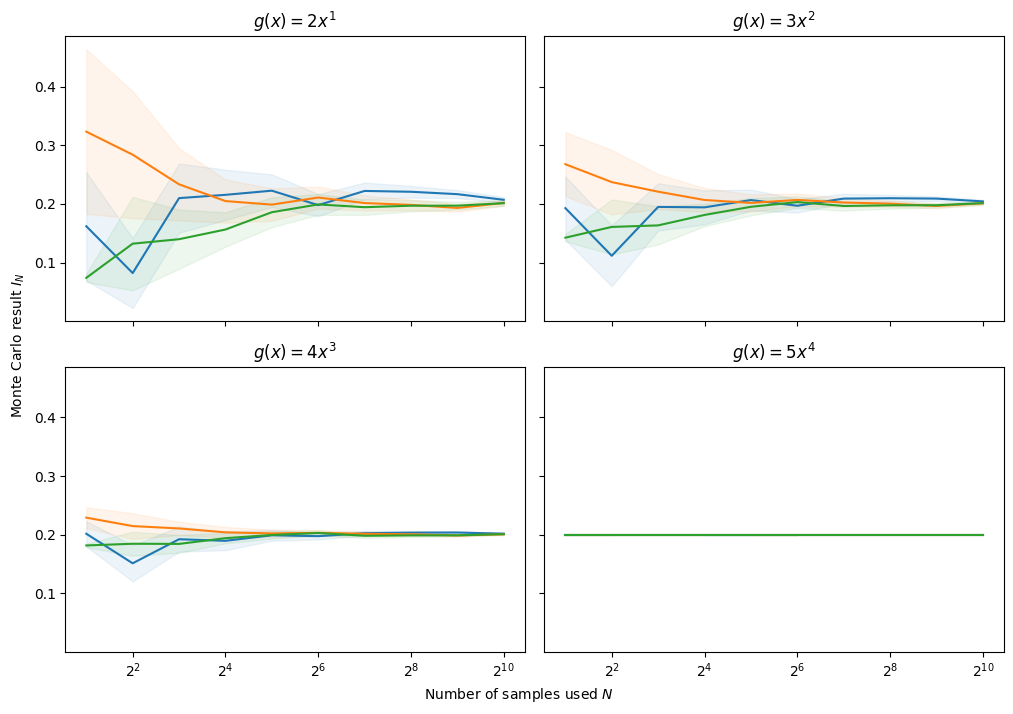

In [ ]:
L=3
exact = primitive_f(1)
fig, axs = plt.subplots(2,2, sharey=True, sharex=True, figsize=(10,7))

for i in range(2,6):
    ax = axs.flat[i-2]
    g = lambda x : i*x**(i-1)
    G = lambda x : x**i
    G_inverse = lambda x : x**(1/i)
    x = np.arange(1,11)
    I, σ = np.empty((len(x), L)), np.empty((len(x), L))
    ax.set_title(f"$g(x)={i}x^{i-1}$")

    for j in x:
        I[j-1], σ[j-1] = np.array([monte_carlo_with_importance_sampling(f, G(a), G(b), 2**j, g, G_inverse, seed=l) for l in range(L)]).T
    for l in range(L):
        line, = ax.semilogx(2**x, I[:,l], base=2)
        ax.fill_between(2**x, I[:,l] - σ[:,l], I[:,l] + σ[:,l], color=line.get_color(), alpha=0.08, zorder=-100)


fig.text(0.5, 0.0, 'Number of samples used $N$', ha='center', va='center')
fig.text(0.0, 0.5, 'Monte Carlo result $I_N$', ha='center', va='center', rotation='vertical')

plt.tight_layout()
plt.show()

<ipython-input-44-ae0c76a98ed5>:28: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(((y_samples**2).mean() - integrand_mean**2)/(N-1))


σ at optimum g:  [0.00000000e+00 1.52084340e-09            nan 0.00000000e+00
 0.00000000e+00 4.69342461e-10            nan            nan
            nan            nan]
σ at optimum g:  [0.00000000e+00 0.00000000e+00            nan            nan
 0.00000000e+00 4.69342461e-10            nan            nan
            nan            nan]
σ at optimum g:  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 4.69342461e-10            nan            nan
            nan            nan]
σ at optimum g:  [nan nan nan  0.  0.  0. nan nan nan nan]
σ at optimum g:  [ 0.  0. nan nan nan  0. nan nan nan nan]


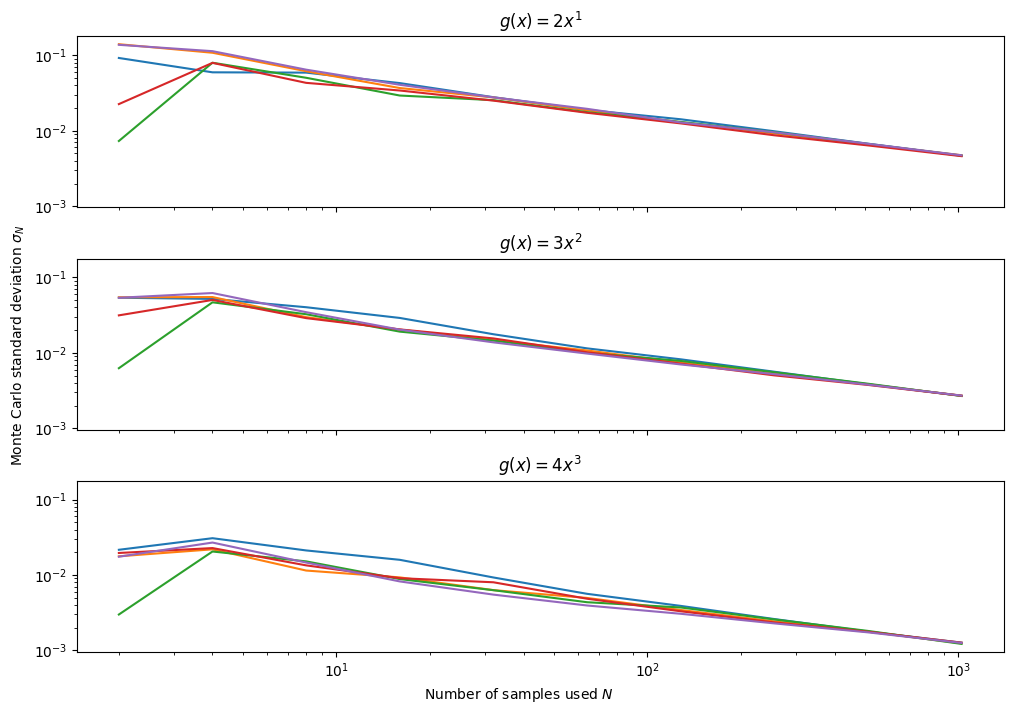

In [ ]:
P=5
exact = primitive_f(1)
fig, axs = plt.subplots(3,1, sharey=True, sharex=True, figsize=(10,7))

for i in range(2,6):
    g = lambda x : i*x**(i-1)
    G = lambda x : x**i
    G_inverse = lambda x : x**(1/i)
    x = np.arange(1,11)
    I, σ = np.empty((len(x), P)), np.empty((len(x), P))
    for j in x:
        I[j-1], σ[j-1] = np.array([monte_carlo_with_importance_sampling(f, G(a), G(b), 2**j, g, G_inverse, seed=p) for p in range(P)]).T
    if i < 5:
      ax = axs.flat[i-2]
      ax.set_title(f"$g(x)={i}x^{i-1}$")
      for p in range(P):
          ax.loglog(2**x, σ[:,p], base=10)
    else:
      for p in range(P):
        print('σ at optimum g: ', σ[:,p])


fig.text(0.5, 0.0, 'Number of samples used $N$', ha='center', va='center')
fig.text(0.0, 0.5, 'Monte Carlo standard deviation $σ_N$', ha='center', va='center', rotation='vertical')

plt.tight_layout()
plt.show()